# Notebook 05 — Model Evaluation

Loads every model's test-set predictions and computes:
- **RMSE** — Root Mean Square Error
- **MAE** — Mean Absolute Error
- **MAPE** — Mean Absolute Percentage Error
- **R²** — Coefficient of Determination

Produces:
- Side-by-side metric comparison tables & bar charts
- Actual vs predicted overlays for all 5 models
- Deep learning training / validation loss curves
- Best-model summary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

MODELS = os.path.join('..', 'models')
FIGS   = os.path.join('..', 'notebooks', 'figures')
os.makedirs(FIGS, exist_ok=True)

with open(os.path.join(MODELS, 'all_predictions.pkl'), 'rb') as f:
    res = pickle.load(f)

MODEL_NAMES = ['Random Forest', 'XGBoost', 'LSTM', 'GRU', 'CNN-LSTM']
PJM_KEYS    = ['RF_PJM',  'XGB_PJM',  'LSTM_PJM',  'GRU_PJM',  'CNNLSTM_PJM']
UCI_KEYS    = ['RF_UCI',  'XGB_UCI',  'LSTM_UCI',  'GRU_UCI',  'CNNLSTM_UCI']
PALETTE     = ['#4472C4','#ED7D31','#70AD47','#FFC000','#7030A0']

print('Loaded predictions for:', list(res.keys()))

Loaded predictions for: ['RF_PJM', 'RF_UCI', 'XGB_PJM', 'XGB_UCI', 'LSTM_PJM', 'LSTM_UCI', 'GRU_PJM', 'GRU_UCI', 'CNNLSTM_PJM', 'CNNLSTM_UCI']


In [2]:
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, mape, r2

def build_table(keys, names):
    rows = []
    for k, n in zip(keys, names):
        rmse, mae, mape, r2 = compute_metrics(res[k]['true'], res[k]['pred'])
        rows.append({'Model': n, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'R²': r2})
    return pd.DataFrame(rows).set_index('Model')

pjm_df = build_table(PJM_KEYS, MODEL_NAMES)
uci_df = build_table(UCI_KEYS, MODEL_NAMES)
print('Metrics computed for all models.')

Metrics computed for all models.


---
## PJM East — Results

In [3]:
print('=' * 60)
print('PJM East — Model Performance (test set, original MW scale)')
print('=' * 60)
display_pjm = pjm_df.copy()
display_pjm['RMSE']     = display_pjm['RMSE'].map('{:,.2f} MW'.format)
display_pjm['MAE']      = display_pjm['MAE'].map('{:,.2f} MW'.format)
display_pjm['MAPE (%)'] = display_pjm['MAPE (%)'].map('{:.2f}%'.format)
display_pjm['R²']       = display_pjm['R²'].map('{:.4f}'.format)
print(display_pjm.to_string())

pjm_df.round(4).to_csv(os.path.join(FIGS, 'pjm_metrics.csv'))
print('\nSaved → figures/pjm_metrics.csv')

PJM East — Model Performance (test set, original MW scale)
                      RMSE          MAE MAPE (%)      R²
Model                                                   
Random Forest    387.94 MW    270.74 MW    0.87%  0.9962
XGBoost          436.57 MW    325.77 MW    1.06%  0.9952
LSTM             536.77 MW    412.25 MW    1.35%  0.9928
GRU            1,755.82 MW  1,415.41 MW    4.74%  0.9227
CNN-LSTM       1,868.88 MW  1,491.27 MW    4.93%  0.9124

Saved → figures/pjm_metrics.csv


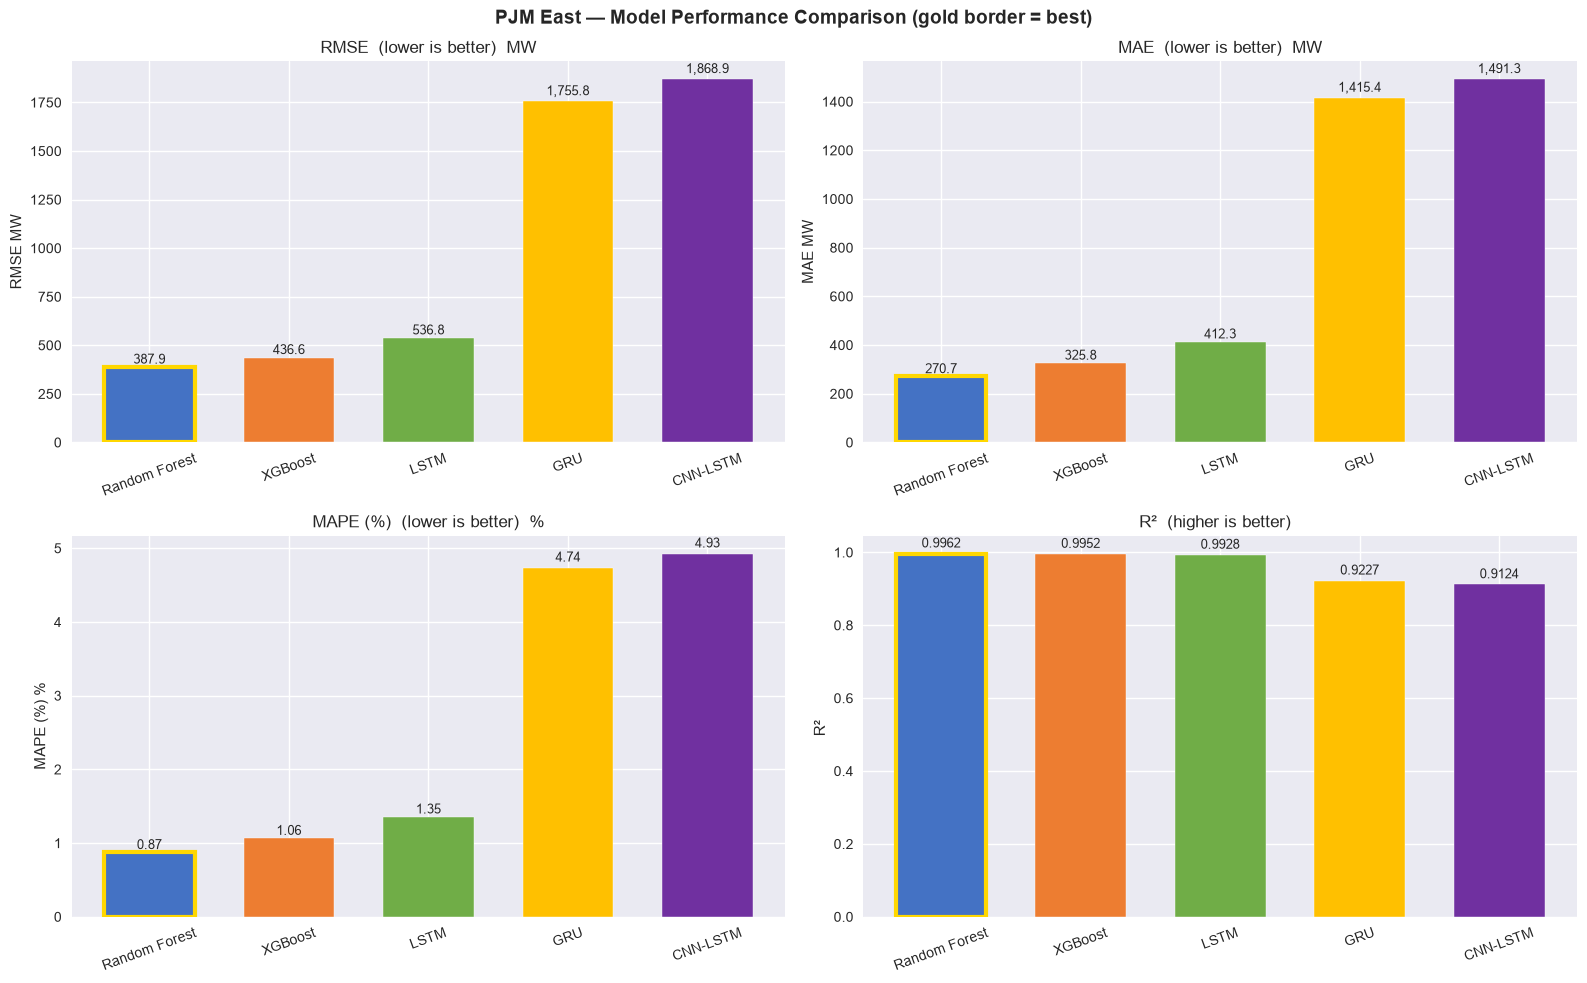

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics_cfg = [
    ('RMSE',     'lower', 'MW'),
    ('MAE',      'lower', 'MW'),
    ('MAPE (%)', 'lower', '%'),
    ('R²',       'higher', ''),
]

for ax, (metric, direction, unit) in zip(axes.flat, metrics_cfg):
    vals  = pjm_df[metric].values
    bars  = ax.bar(MODEL_NAMES, vals, color=PALETTE, edgecolor='white', width=0.65)
    best  = int(np.argmin(vals) if direction == 'lower' else np.argmax(vals))
    bars[best].set_edgecolor('gold'); bars[best].set_linewidth(3)
    for bar in bars:
        h = bar.get_height()
        lbl = f'{h:,.1f}' if metric in ('RMSE','MAE') else (f'{h:.2f}' if metric == 'MAPE (%)' else f'{h:.4f}')
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.01, lbl,
                ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{metric}  ({direction} is better)  {unit}', fontsize=12)
    ax.set_ylabel(f'{metric} {unit}')
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('PJM East — Model Performance Comparison (gold border = best)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'pjm_comparison.png'), bbox_inches='tight', dpi=120)
plt.show()

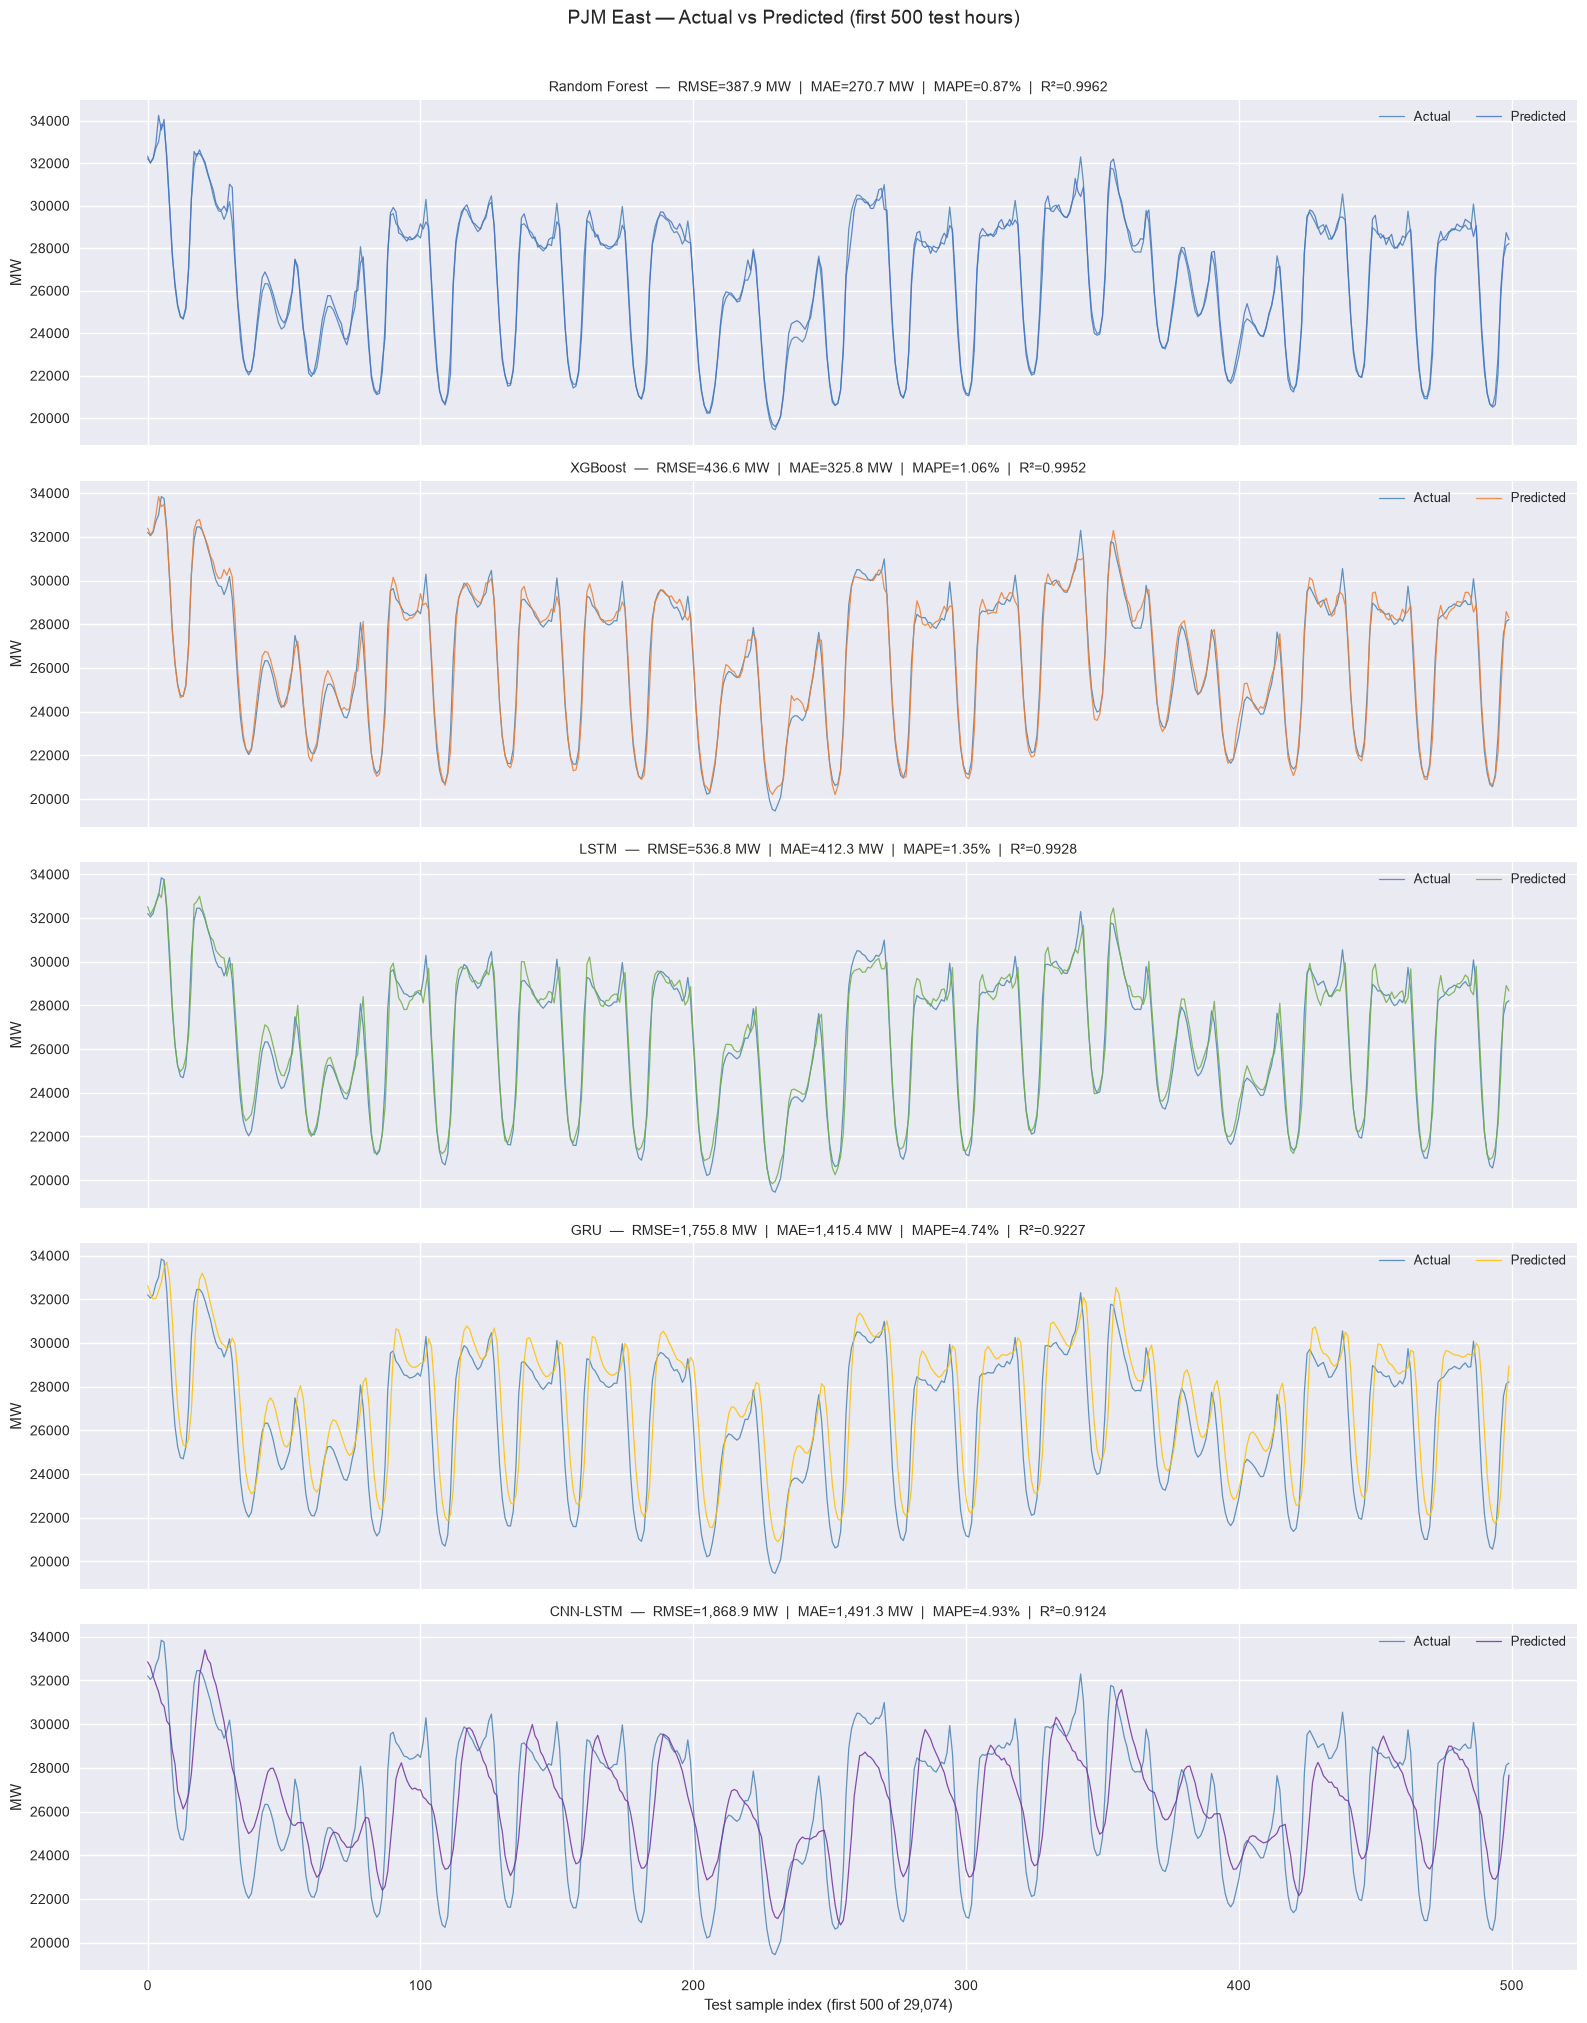

In [5]:
N = 500   # show first 500 test-set hours for clarity
fig, axes = plt.subplots(5, 1, figsize=(16, 20), sharex=True)

for ax, key, name, colour in zip(axes, PJM_KEYS, MODEL_NAMES, PALETTE):
    y_true = res[key]['true'][:N]
    y_pred = res[key]['pred'][:N]
    rmse, mae, mape, r2 = compute_metrics(res[key]['true'], res[key]['pred'])
    ax.plot(y_true, lw=0.9, color='steelblue', label='Actual', alpha=0.85)
    ax.plot(y_pred, lw=0.9, color=colour,      label='Predicted', alpha=0.85)
    ax.set_title(
        f'{name}  —  RMSE={rmse:,.1f} MW  |  MAE={mae:,.1f} MW  |  MAPE={mape:.2f}%  |  R²={r2:.4f}',
        fontsize=10)
    ax.set_ylabel('MW')
    ax.legend(loc='upper right', fontsize=9, ncol=2)

axes[-1].set_xlabel(f'Test sample index (first {N} of {len(res[PJM_KEYS[0]]["true"]):,})')
fig.suptitle('PJM East — Actual vs Predicted (first 500 test hours)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'pjm_actual_vs_pred.png'), bbox_inches='tight', dpi=120)
plt.show()

---
## UCI Household — Results

In [6]:
print('=' * 60)
print('UCI Household — Model Performance (test set, original kW scale)')
print('=' * 60)
display_uci = uci_df.copy()
display_uci['RMSE']     = display_uci['RMSE'].map('{:.4f} kW'.format)
display_uci['MAE']      = display_uci['MAE'].map('{:.4f} kW'.format)
display_uci['MAPE (%)'] = display_uci['MAPE (%)'].map('{:.2f}%'.format)
display_uci['R²']       = display_uci['R²'].map('{:.4f}'.format)
print(display_uci.to_string())

uci_df.round(4).to_csv(os.path.join(FIGS, 'uci_metrics.csv'))
print('\nSaved → figures/uci_metrics.csv')

UCI Household — Model Performance (test set, original kW scale)
                    RMSE        MAE MAPE (%)      R²
Model                                               
Random Forest  0.4778 kW  0.3339 kW   44.36%  0.5562
XGBoost        0.4728 kW  0.3302 kW   44.47%  0.5655
LSTM           0.6848 kW  0.5487 kW   82.00%  0.0881
GRU            0.5931 kW  0.4541 kW   67.07%  0.3160
CNN-LSTM       0.6818 kW  0.5542 kW   86.06%  0.0962

Saved → figures/uci_metrics.csv


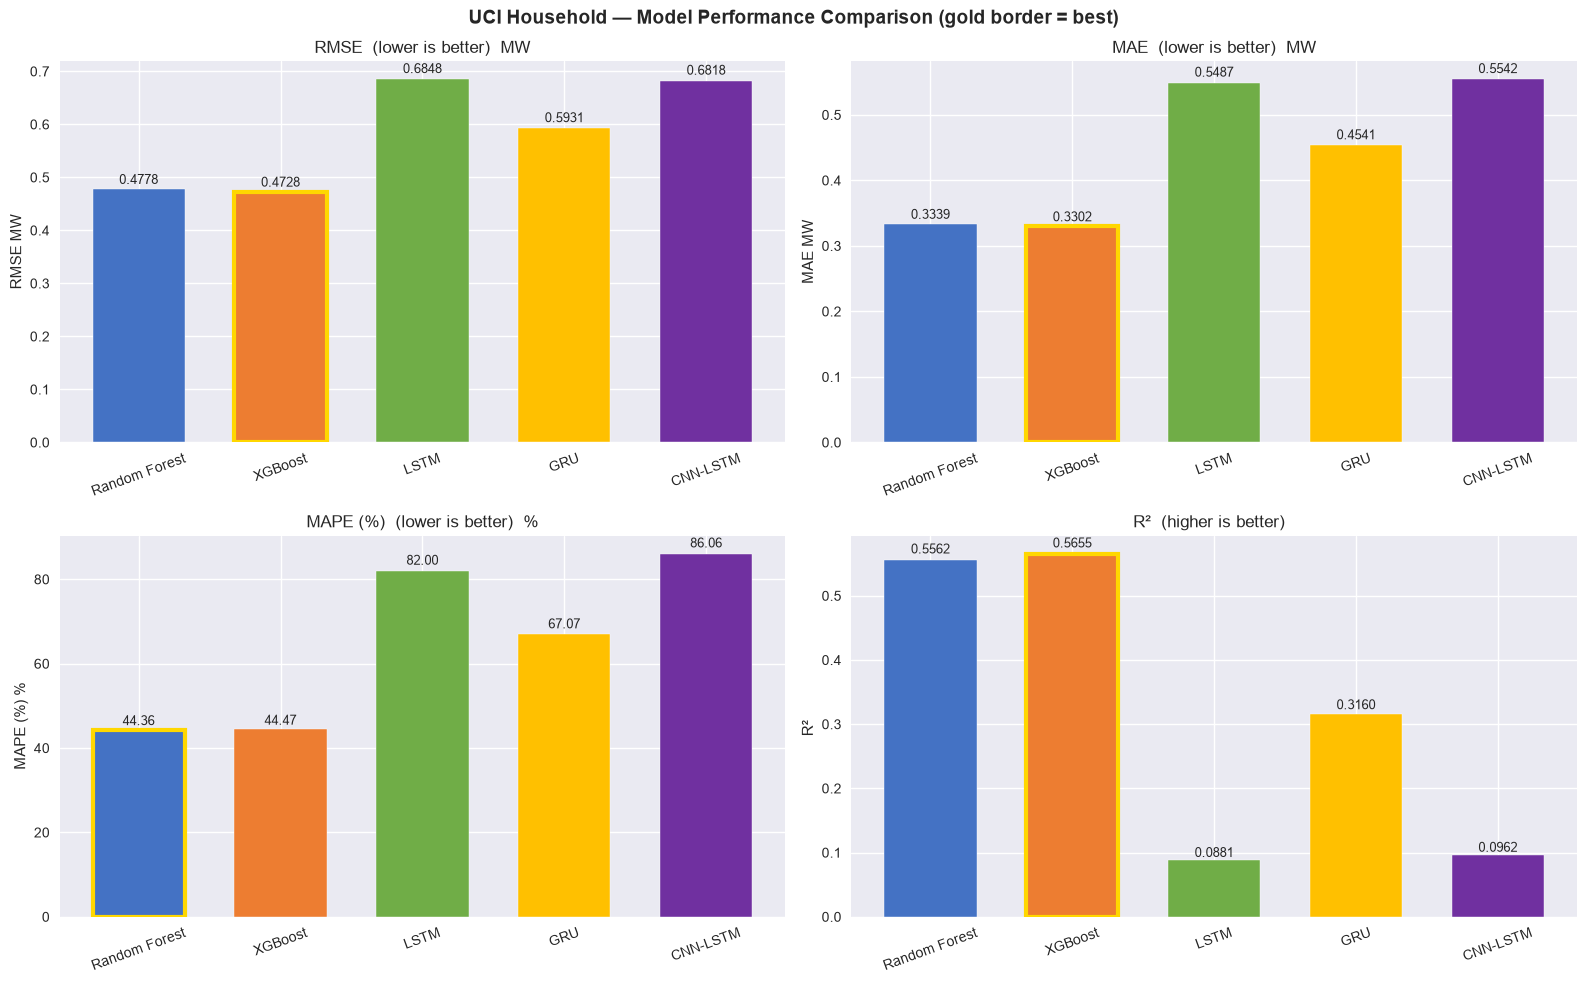

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (metric, direction, unit) in zip(axes.flat, metrics_cfg):
    vals  = uci_df[metric].values
    bars  = ax.bar(MODEL_NAMES, vals, color=PALETTE, edgecolor='white', width=0.65)
    best  = int(np.argmin(vals) if direction == 'lower' else np.argmax(vals))
    bars[best].set_edgecolor('gold'); bars[best].set_linewidth(3)
    for bar in bars:
        h = bar.get_height()
        lbl = f'{h:.4f}' if metric in ('RMSE','MAE') else (f'{h:.2f}' if metric == 'MAPE (%)' else f'{h:.4f}')
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.01, lbl,
                ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{metric}  ({direction} is better)  {unit}', fontsize=12)
    ax.set_ylabel(f'{metric} {unit}')
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('UCI Household — Model Performance Comparison (gold border = best)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'uci_comparison.png'), bbox_inches='tight', dpi=120)
plt.show()

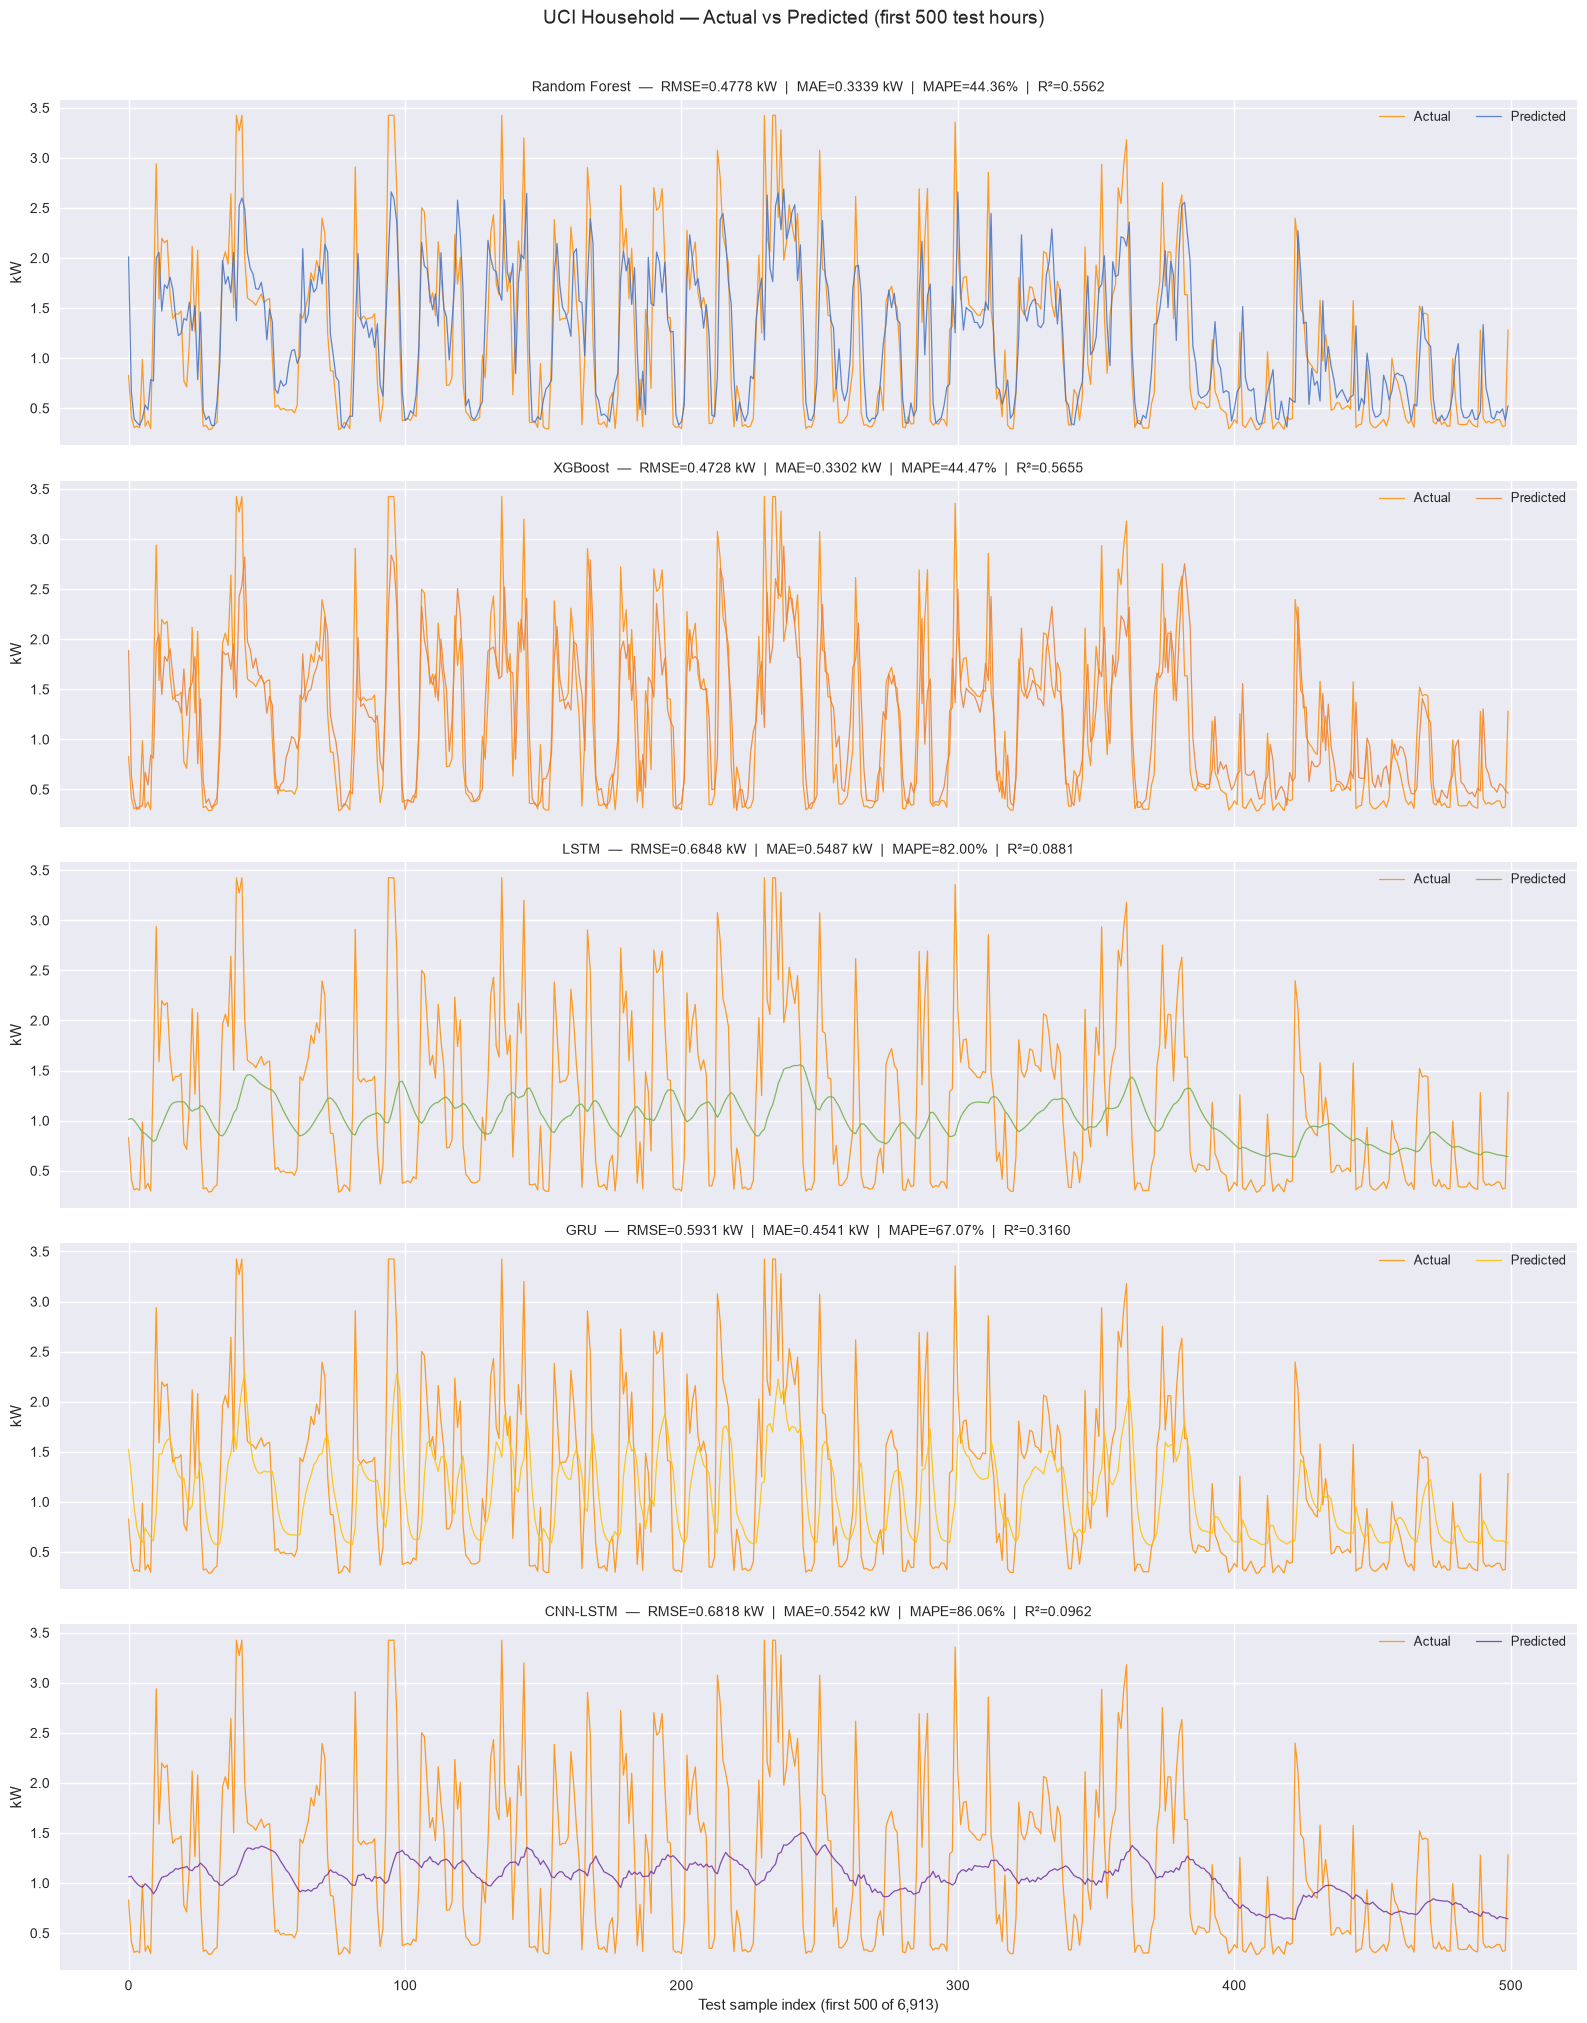

In [8]:
N = 500
fig, axes = plt.subplots(5, 1, figsize=(16, 20), sharex=True)

for ax, key, name, colour in zip(axes, UCI_KEYS, MODEL_NAMES, PALETTE):
    y_true = res[key]['true'][:N]
    y_pred = res[key]['pred'][:N]
    rmse, mae, mape, r2 = compute_metrics(res[key]['true'], res[key]['pred'])
    ax.plot(y_true, lw=0.9, color='darkorange', label='Actual', alpha=0.85)
    ax.plot(y_pred, lw=0.9, color=colour,       label='Predicted', alpha=0.85)
    ax.set_title(
        f'{name}  —  RMSE={rmse:.4f} kW  |  MAE={mae:.4f} kW  |  MAPE={mape:.2f}%  |  R²={r2:.4f}',
        fontsize=10)
    ax.set_ylabel('kW')
    ax.legend(loc='upper right', fontsize=9, ncol=2)

axes[-1].set_xlabel(f'Test sample index (first {N} of {len(res[UCI_KEYS[0]]["true"]):,})')
fig.suptitle('UCI Household — Actual vs Predicted (first 500 test hours)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'uci_actual_vs_pred.png'), bbox_inches='tight', dpi=120)
plt.show()

---
## Deep Learning — Training Loss Curves

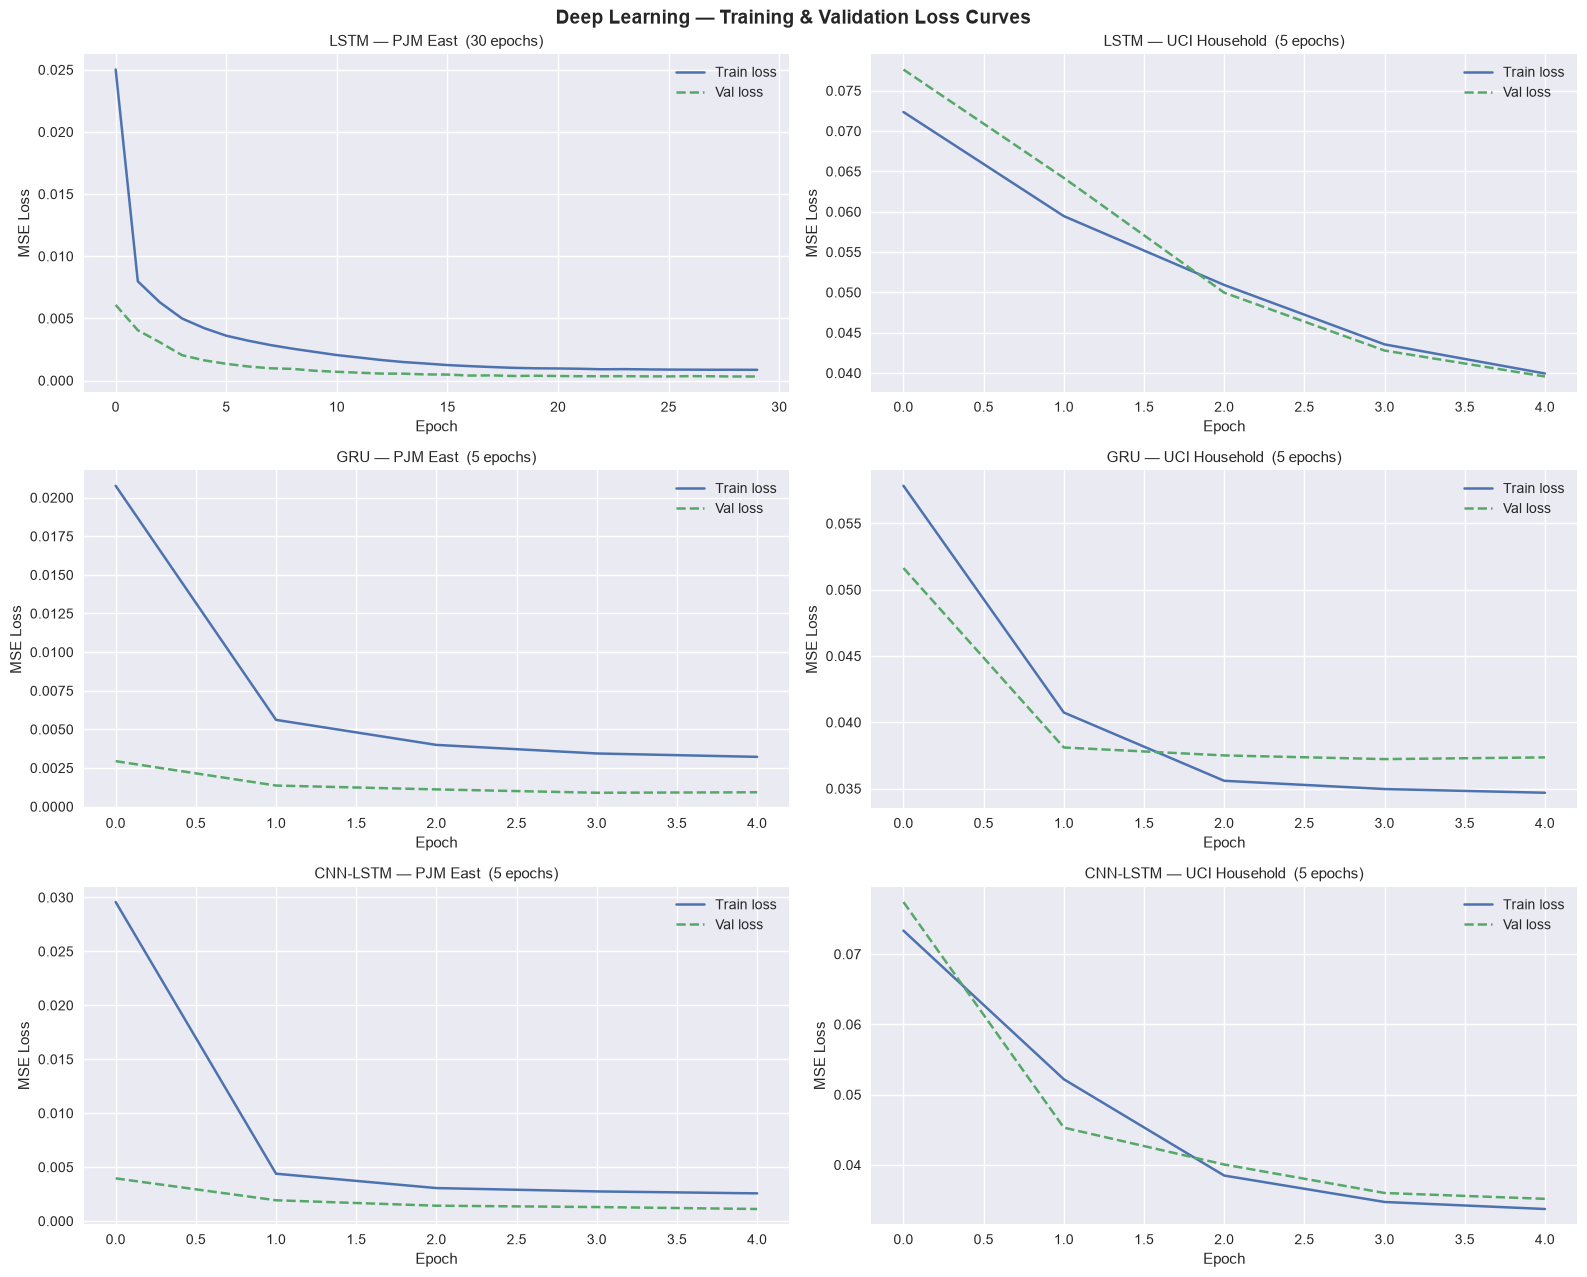

In [9]:
dl_keys   = ['lstm',   'gru',   'cnnlstm']
dl_names  = ['LSTM',   'GRU',   'CNN-LSTM']
datasets  = [('pjm', 'PJM East'), ('uci', 'UCI Household')]

fig, axes = plt.subplots(3, 2, figsize=(16, 13))

for i, (key, name) in enumerate(zip(dl_keys, dl_names)):
    for j, (ds, ds_label) in enumerate(datasets):
        hist_path = os.path.join(MODELS, f'hist_{key}_{ds}.pkl')
        with open(hist_path, 'rb') as f:
            hist = pickle.load(f)
        ax = axes[i][j]
        ax.plot(hist['loss'],     lw=1.8, label='Train loss')
        ax.plot(hist['val_loss'], lw=1.8, label='Val loss',  ls='--')
        epochs_run = len(hist['loss'])
        ax.set_title(f'{name} — {ds_label}  ({epochs_run} epochs)', fontsize=11)
        ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
        ax.legend()

fig.suptitle('Deep Learning — Training & Validation Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'dl_training_curves.png'), bbox_inches='tight', dpi=120)
plt.show()

---
## Final Summary

In [10]:
# ── Combined ranked table ────────────────────────────────────────
print('\n' + '=' * 65)
print('FINAL MODEL RANKINGS')
print('=' * 65)

for df, label, unit in [(pjm_df, 'PJM East', 'MW'), (uci_df, 'UCI Household', 'kW')]:
    print(f'\n  {label}:')
    print(f'    Best RMSE  : {df["RMSE"].idxmin():<18s} {df["RMSE"].min():.4f} {unit}')
    print(f'    Best MAE   : {df["MAE"].idxmin():<18s} {df["MAE"].min():.4f} {unit}')
    print(f'    Best MAPE  : {df["MAPE (%)"].idxmin():<18s} {df["MAPE (%)"].min():.2f}%')
    print(f'    Best R²    : {df["R²"].idxmax():<18s} {df["R²"].max():.4f}')

# ── Score by number of top-3 metric wins ────────────────────────
print('\n' + '-' * 65)
print('Metric-win count (how many of 4 metrics each model wins):')
for df, label in [(pjm_df, 'PJM'), (uci_df, 'UCI')]:
    wins = {m: 0 for m in MODEL_NAMES}
    for metric in ['RMSE', 'MAE', 'MAPE (%)']:
        wins[df[metric].idxmin()] += 1
    wins[df['R²'].idxmax()] += 1
    sorted_wins = sorted(wins.items(), key=lambda x: x[1], reverse=True)
    print(f'  {label}:', '  |  '.join(f'{m}: {w}' for m, w in sorted_wins))


FINAL MODEL RANKINGS

  PJM East:
    Best RMSE  : Random Forest      387.9386 MW
    Best MAE   : Random Forest      270.7438 MW
    Best MAPE  : Random Forest      0.87%
    Best R²    : Random Forest      0.9962

  UCI Household:
    Best RMSE  : XGBoost            0.4728 kW
    Best MAE   : XGBoost            0.3302 kW
    Best MAPE  : Random Forest      44.36%
    Best R²    : XGBoost            0.5655

-----------------------------------------------------------------
Metric-win count (how many of 4 metrics each model wins):
  PJM: Random Forest: 4  |  XGBoost: 0  |  LSTM: 0  |  GRU: 0  |  CNN-LSTM: 0
  UCI: XGBoost: 3  |  Random Forest: 1  |  LSTM: 0  |  GRU: 0  |  CNN-LSTM: 0


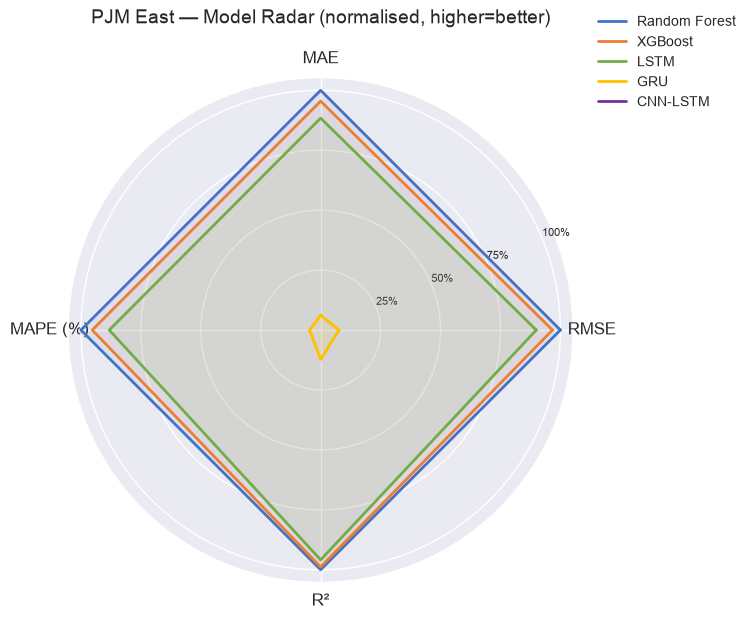

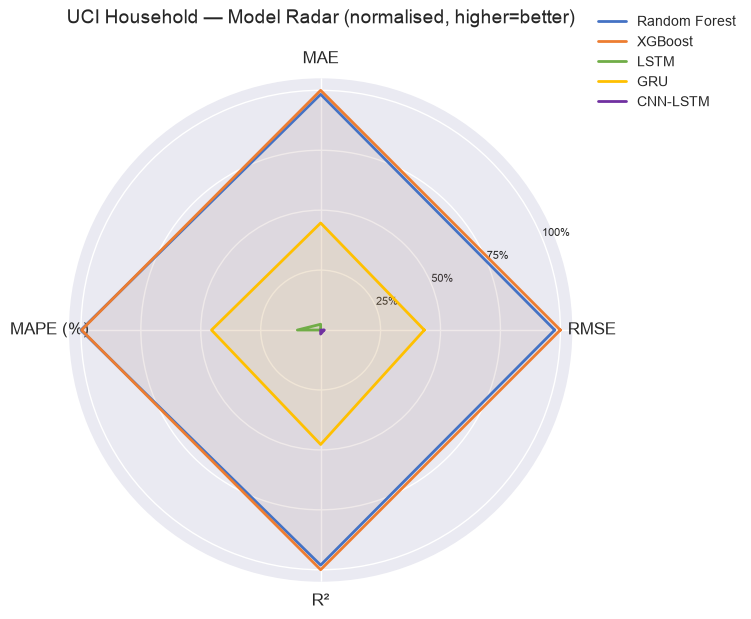

In [11]:
# ── Radar / spider chart — PJM ───────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

def radar_chart(df, title, filepath):
    metrics_r = ['RMSE', 'MAE', 'MAPE (%)', 'R²']
    # Normalise: 0=worst, 1=best for each metric
    norm = df.copy()
    for m in ['RMSE', 'MAE', 'MAPE (%)']:
        lo, hi = norm[m].min(), norm[m].max()
        norm[m] = 1 - (norm[m] - lo) / (hi - lo + 1e-12)   # invert (lower=better)
    lo, hi = norm['R²'].min(), norm['R²'].max()
    norm['R²'] = (norm['R²'] - lo) / (hi - lo + 1e-12)

    N   = len(metrics_r)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    for (model, row), colour in zip(norm.iterrows(), PALETTE):
        values = row[metrics_r].tolist() + [row[metrics_r[0]]]
        ax.plot(angles, values, lw=2, label=model, color=colour)
        ax.fill(angles, values, alpha=0.08, color=colour)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_r, fontsize=12)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=8)
    ax.set_title(title, fontsize=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
    plt.tight_layout()
    plt.savefig(filepath, bbox_inches='tight', dpi=120)
    plt.show()

radar_chart(pjm_df, 'PJM East — Model Radar (normalised, higher=better)',
            os.path.join(FIGS, 'pjm_radar.png'))
radar_chart(uci_df, 'UCI Household — Model Radar (normalised, higher=better)',
            os.path.join(FIGS, 'uci_radar.png'))

In [12]:
# ── Save consolidated metrics to one Excel for dissertation ──────
try:
    with pd.ExcelWriter(os.path.join(FIGS, 'all_metrics.xlsx')) as writer:
        pjm_df.round(4).to_excel(writer, sheet_name='PJM East')
        uci_df.round(4).to_excel(writer, sheet_name='UCI Household')
    print('Saved → figures/all_metrics.xlsx  (paste directly into dissertation)')
except Exception:
    pass   # openpyxl may not be installed

print('\n' + '=' * 65)
print('EVALUATION COMPLETE')
print('=' * 65)
print('\nFigures saved:')
for f in sorted(os.listdir(FIGS)):
    if f.endswith(('.png', '.csv', '.xlsx')):
        kb = os.path.getsize(os.path.join(FIGS, f)) / 1024
        print(f'  {f:<38s}  {kb:>7.1f} KB')

Saved → figures/all_metrics.xlsx  (paste directly into dissertation)

EVALUATION COMPLETE

Figures saved:
  all_metrics.xlsx                            5.7 KB
  dl_training_curves.png                    233.4 KB
  pjm_acf.png                                44.9 KB
  pjm_actual_vs_pred.png                    725.4 KB
  pjm_comparison.png                        109.7 KB
  pjm_decomposition.png                     603.2 KB
  pjm_heatmap.png                            42.3 KB
  pjm_metrics.csv                             0.2 KB
  pjm_patterns.png                           61.2 KB
  pjm_radar.png                             103.5 KB
  pjm_rolling.png                           272.5 KB
  pjm_timeseries.png                        315.0 KB
  uci_acf.png                                41.2 KB
  uci_actual_vs_pred.png                    988.5 KB
  uci_comparison.png                        111.4 KB
  uci_correlation.png                        68.6 KB
  uci_decomposition.png                     38